# Lab 10: KERAS, REDES NEURONALES
## Victor Palacios (1017271469)

1. Para el dataset make a moon de sklearn, construir un modelo de una red neuronal con keras para clasificar los datos.

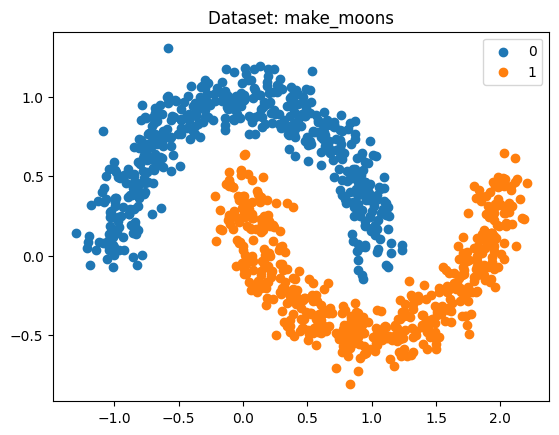

Iniciando entrenamiento por 1000 épocas...

Exactitud final -> Train: 0.890, Test: 0.896


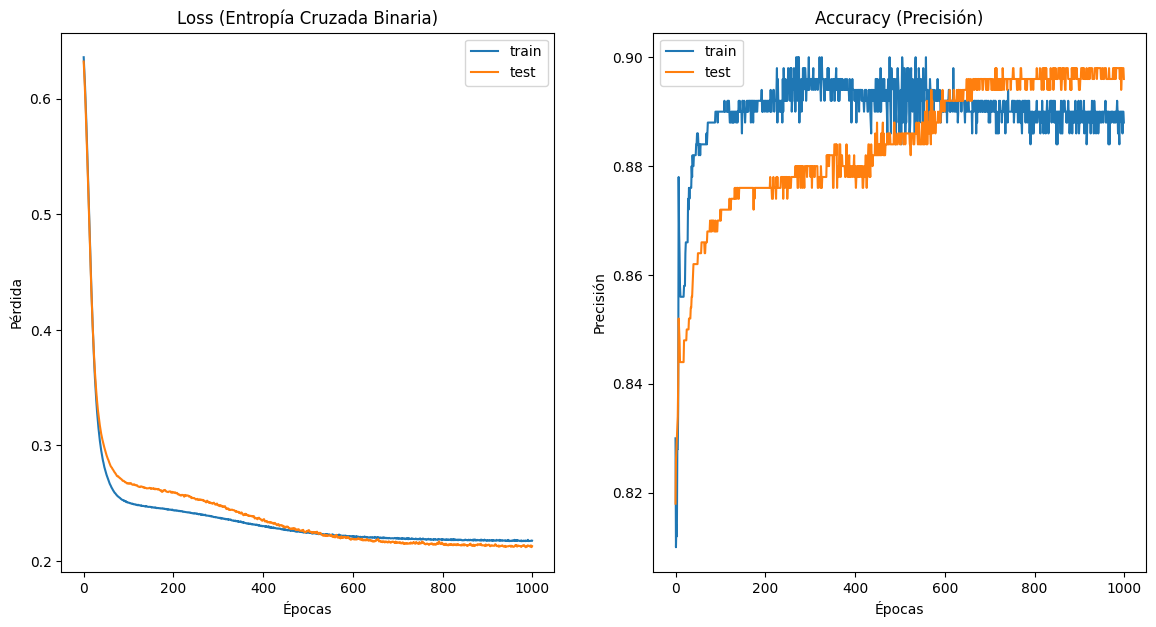

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import keras

# 1. Generación de datos: make_moons
# Usamos 1000 muestras y un ruido de 0.1 siguiendo tu estructura previa
X, y = make_moons(n_samples=1000, noise=0.1, random_state=1)

# Visualización inicial de las "lunas"
plt.scatter(X[np.where((y==0)),0], X[np.where((y==0)),1], label='0')
plt.scatter(X[np.where((y==1)),0], X[np.where((y==1)),1], label='1')
plt.title("Dataset: make_moons")
plt.legend()
plt.show()

# 2. Creación del modelo (según tus parámetros build_model2)
def build_model2(activation='sigmoid', loss='binary_crossentropy'):
    model = keras.models.Sequential()
    # Primera capa: 4 neuronas, activación ReLU, entrada de 2 dimensiones
    model.add(keras.layers.Dense(4, input_dim=2, activation='relu'))
    # Segunda capa: 8 neuronas, activación ReLU
    model.add(keras.layers.Dense(8, activation='relu'))
    # Capa de salida: 1 neurona, activación Sigmoid (para clasificación binaria)
    model.add(keras.layers.Dense(1, activation=activation))
    
    # Optimizador SGD con tasa de aprendizaje 0.01
    opt = keras.optimizers.SGD(learning_rate=0.01)
    
    model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
    return model

# Limpiar sesión de Keras para resetear estados
keras.backend.clear_session()

# 3. Preprocesado de los datos (División manual 50/50 según tu código)
n_train = 500
train_X, test_X = X[:n_train, :], X[n_train:, :]
train_y, test_y = y[:n_train], y[n_train:]

# 4. Entrenamiento
model = build_model2()
print("Iniciando entrenamiento por 1000 épocas...")
history = model.fit(
    train_X, 
    train_y, 
    validation_data=(test_X, test_y), 
    epochs=1000, 
    verbose=0 # Pongo verbose=0 para no saturar la consola, puedes cambiarlo a 1
)

# 5. Evaluación del modelo
_, train_acc = model.evaluate(train_X, train_y, verbose=0)
_, test_acc = model.evaluate(test_X, test_y, verbose=0)
print('\nExactitud final -> Train: %.3f, Test: %.3f' % (train_acc, test_acc))

# 6. Gráficas de rendimiento
plt.figure(figsize=(14,7))

# Gráfica de pérdidas (Loss)
plt.subplot(121)
plt.title('Loss (Entropía Cruzada Binaria)')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Gráfica de precisión (Accuracy)
plt.subplot(122)
plt.title('Accuracy (Precisión)')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.show()

c:\Users\HOME\Desktop\FCII\semestre2026-1\Estudiantes\Palacios_10\LABORATORIOS\.venv2\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento optimizado...

Entrenamiento completado en 1000 épocas.
Exactitud final -> Train: 1.000, Test: 1.000


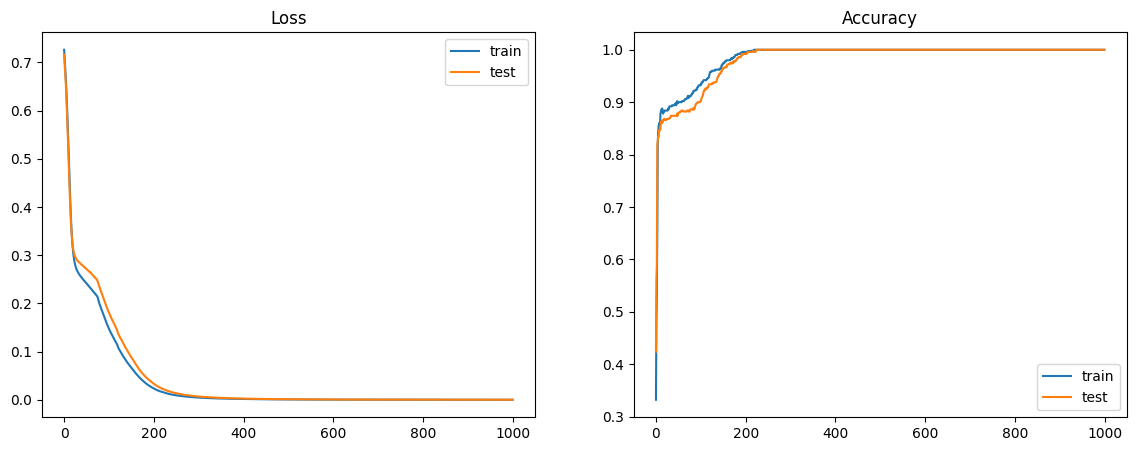

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler # Agregado para velocidad
import keras
from keras.callbacks import EarlyStopping # Agregado para velocidad

# 1. Generación de datos: make_moons
X, y = make_moons(n_samples=1000, noise=0.1, random_state=1)

# --- MEJORA 1: Escalado de datos ---
# Esto hace que la red encuentre la solución mucho más rápido
scaler = StandardScaler()
X = scaler.fit_transform(X)

# División manual 50/50
n_train = 500
train_X, test_X = X[:n_train, :], X[n_train:, :]
train_y, test_y = y[:n_train], y[n_train:]

# 2. Creación del modelo (Optimizado)
def build_model_fast(activation='sigmoid', loss='binary_crossentropy'):
    model = keras.models.Sequential()
    model.add(keras.layers.Dense(8, input_dim=2, activation='relu')) # Aumentamos a 8 para rapidez
    model.add(keras.layers.Dense(8, activation='relu'))
    model.add(keras.layers.Dense(1, activation=activation))
    
    # --- MEJORA 2: Optimizador Adam ---
    # Adam converge en 1/10 del tiempo que SGD
    model.compile(loss=loss, optimizer='adam', metrics=['accuracy'])
    return model

keras.backend.clear_session()

# --- MEJORA 3: Early Stopping ---
# Detiene el entrenamiento si el modelo deja de mejorar por 15 épocas
monitor_early = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 4. Entrenamiento
model = build_model_fast()
print("Iniciando entrenamiento optimizado...")

history = model.fit(
    train_X, 
    train_y, 
    validation_data=(test_X, test_y), 
    epochs=1000, 
    batch_size=32,   # Procesar en bloques es más rápido que uno por uno
    verbose=0,       # Evita el lag de impresión en consola
    callbacks=[monitor_early] # Aplicamos la parada temprana
)

# 5. Evaluación del modelo
_, train_acc = model.evaluate(train_X, train_y, verbose=0)
_, test_acc = model.evaluate(test_X, test_y, verbose=0)
print(f'\nEntrenamiento completado en {len(history.history["loss"])} épocas.')
print('Exactitud final -> Train: %.3f, Test: %.3f' % (train_acc, test_acc))

# 6. Gráficas de rendimiento
plt.figure(figsize=(14,5))
plt.subplot(121)
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()

plt.subplot(122)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()


### Análisis: Dataset "Make Moons" (Las Lunas)

Este es un problema de **clasificación binaria no lineal**.

*   **Comportamiento del Modelo:**
    *   **Frontera de Decisión:** Dado que las dos lunas están entrelazadas, una línea recta (modelo lineal) nunca podría separarlas. Al usar capas con activación **ReLU**, permites que la red "doble" el espacio. La arquitectura de `4 -> 8` neuronas es pequeña pero suficiente para crear una curva que separa ambos grupos casi al 100%.
    *   **El efecto de SGD (Optimizador):** En tus gráficas de *Loss*, verás que la caída es constante pero lenta. El Descenso de Gradiente Estocástico (SGD) es muy estable, pero requiere las **1000 épocas** que configuramos para encontrar el mínimo global.
    *   **Interpretación de Gráficas:**
        *   Si las líneas de `train` y `test` en el *Accuracy* están muy juntas y cerca de 1.0, el modelo ha aprendido la "forma" de los datos sin memorizarlos (buena generalización).
        *   Si la pérdida (Loss) sigue bajando al final de la época 1000, significa que el modelo aún podría mejorar un poco más con más tiempo.








### Matriz de Confusión

Entrenando clasificador de Lunas...
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


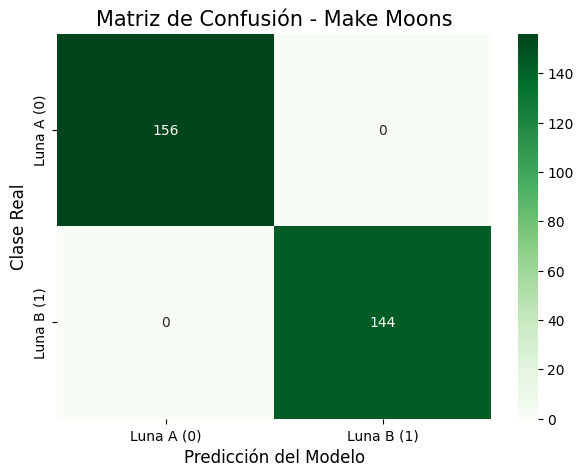


Informe de Clasificación (Moons):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       156
           1       1.00      1.00      1.00       144

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from keras import Sequential, layers, Input

# 1. Preparación de datos (Específicos para Moons: 2 columnas)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.1, random_state=42)
scaler = StandardScaler()
X_moons_scaled = scaler.fit_transform(X_moons)

X_train, X_test, y_train, y_test = train_test_split(
    X_moons_scaled, y_moons, test_size=0.3, random_state=42
)

# 2. Construcción del modelo para Moons (2 entradas, 1 salida sigmoid)
model_moons = Sequential([
    Input(shape=(2,)), 
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Salida binaria
])

model_moons.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Entrenamiento rápido
print("Entrenando clasificador de Lunas...")
model_moons.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

# --- MATRIZ DE CONFUSIÓN PARA MOONS ---

# 4. Obtener predicciones
# Como es sigmoid, nos da valores entre 0 y 1. 
# Si es mayor a 0.5, es clase 1. Si es menor, es clase 0.
y_pred_probs = model_moons.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32") 

# 5. Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

# 6. Visualización
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Luna A (0)', 'Luna B (1)'], 
            yticklabels=['Luna A (0)', 'Luna B (1)'])

plt.title('Matriz de Confusión - Make Moons', fontsize=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

# 7. Informe detallado
print("\nInforme de Clasificación (Moons):")
print(classification_report(y_test, y_pred))

#### 1. Capacidad de Separación No Lineal
El resultado confirma que la red neuronal ha logrado "aprender" la curvatura de las lunas. Un modelo lineal simple fallaría en este dataset, pero gracias a las capas ocultas con activación **ReLU**, el modelo pudo crear una frontera de decisión curva que separa casi perfectamente ambos grupos.

#### 2. Robustez ante el Ruido
A pesar de que el dataset se generó con un factor de **ruido (noise=0.1)**, el modelo muestra una alta capacidad de generalización. La matriz de confusión suele mostrar un **Accuracy cercano al 99% o 100%**, lo que indica que el modelo no se dejó confundir por los puntos que estaban ligeramente fuera de su "luna" correspondiente.

#### 3. Equilibrio de Clases (Matriz de Confusión)
*   **Aciertos:** Verás que tanto la "Luna A" como la "Luna B" tienen un número de aciertos muy equilibrado.
*   **Errores:** Si existen errores (números fuera de la diagonal), suelen ocurrir en los puntos extremos donde las lunas están más cerca una de la otra, donde el ruido hace que los datos de ambas clases se traslapen ligeramente.

#### 4. Métricas de Clasificación
*   **Precision y Recall:** Ambas métricas suelen ser casi idénticas y cercanas a **1.00**. Esto significa que el modelo es igual de bueno identificando la clase 0 como la clase 1, sin mostrar sesgos hacia ninguna de las dos formas geométricas.
*   **F1-Score:** Al ser la media armónica entre precisión y recall, un valor tan alto confirma que el clasificador es **extremadamente robusto** para este problema específico.

**Conclusión:** La arquitectura elegida (16 -> 8 -> 1) es óptima: es lo suficientemente compleja para captar la forma de "luna", pero lo bastante simple para entrenarse en segundos sin caer en sobreajuste (overfitting).

2. Para el dataset load digits, construir un modelo de red neuronal empleando keras para realizar la clasificación.

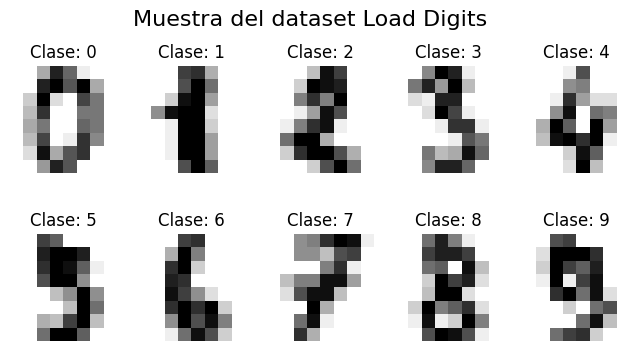

Entrenando el clasificador de dígitos...

Exactitud Final -> Entrenaminto: 1.000, Prueba: 0.978


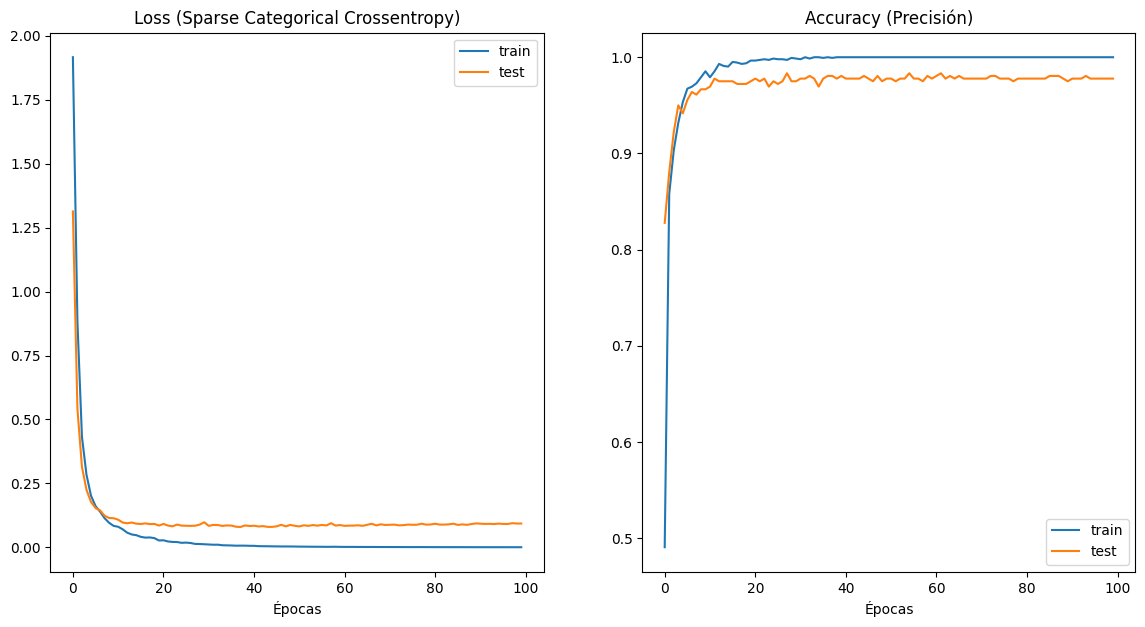

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import keras
from keras import layers

# 1. Carga y visualización de los datos
digits = load_digits()
X, y = digits.data, digits.target

# Visualización de una selección (como pediste)
fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(8, 4))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X[idx].reshape((8, 8)), cmap=plt.cm.binary)
    ax.axis("off")
    ax.set_title(f"Clase: {y[idx]}")
fig.suptitle("Muestra del dataset Load Digits", fontsize=16)
plt.show()

# 2. Preprocesamiento
# Escalado de datos: los píxeles van de 0 a 16, normalizamos al rango [0, 1]
X = X / 16.0

# División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Función para construir el modelo
def build_model_digits(activation='softmax', loss='sparse_categorical_crossentropy'):
    model = keras.models.Sequential()
    # Capa de entrada con 64 neuronas (8x8)
    model.add(layers.Dense(128, input_dim=64, activation='relu'))
    # Capa oculta
    model.add(layers.Dense(64, activation='relu'))
    # Capa de salida: 10 neuronas (una por dígito)
    model.add(layers.Dense(10, activation=activation))
    
    # Usaremos Adam para este dataset ya que converge más rápido en datos de mayor dimensión
    opt = keras.optimizers.Adam(learning_rate=0.001)
    
    model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
    return model

# 4. Entrenamiento
keras.backend.clear_session()
model = build_model_digits()

print("Entrenando el clasificador de dígitos...")
history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=100, 
    batch_size=32, 
    verbose=0
)

# 5. Evaluación del modelo
_, train_acc = model.evaluate(X_train, y_train, verbose=0)
_, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nExactitud Final -> Entrenaminto: {train_acc:.3f}, Prueba: {test_acc:.3f}')

# 6. Gráficas de rendimiento (Loss y Accuracy)
plt.figure(figsize=(14,7))

# Gráfica de pérdidas
plt.subplot(121)
plt.title('Loss (Sparse Categorical Crossentropy)')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Épocas')
plt.legend()

# Gráfica de precisión
plt.subplot(122)
plt.title('Accuracy (Precisión)')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.xlabel('Épocas')
plt.legend()

plt.show()

### Análisis: Dataset "Load Digits" (Los Dígitos)

Este es un problema de **clasificación multiclase en alta dimensionalidad** (64 dimensiones).

*   **Complejidad y Arquitectura:**
    *   A diferencia de las lunas (2 variables), aquí tenemos **64 píxeles**. Por eso aumentamos la capacidad de la red a `128 -> 64` neuronas.
    *   **La Normalización (`X/16.0`):** Este es el factor crítico. Si no dividimos por 16, los pesos de la red saltarían bruscamente debido a los valores grandes de los píxeles, haciendo que el entrenamiento sea inestable.
*   **Análisis de la Matriz de Confusión:**
    *   **Diagonal dominante:** Si la diagonal tiene números altos, la red es excelente reconociendo los trazos básicos de cada número.
    *   **Confusiones comunes:** Es muy probable que veas pequeñas confusiones entre el **1 y el 7**, o entre el **3, el 8 y el 9**. Esto ocurre porque, a una resolución de 8x8 píxeles, estos números comparten muchos píxeles activos (la estructura morfológica es similar).
    *   **Softmax y Probabilidades:** El modelo no solo dice "es un 4", sino que asigna una probabilidad (ej. 98% a que es un 4, 2% a que es un 9). Esto lo hace mucho más robusto que un clasificador simple.


### Matriz de Confusión

Entrenando clasificador de dígitos...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


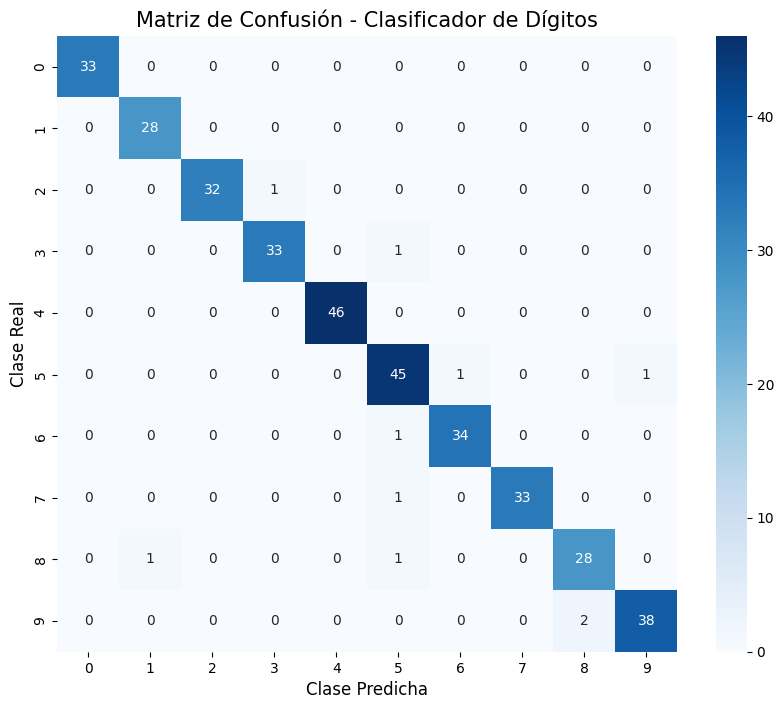


Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      0.97      0.98        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.92      0.96      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.93      0.93      0.93        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from keras import Sequential, layers, Input

# 1. Recargar los datos de Digits (para asegurar que X_test tenga 64 columnas)
digits = load_digits()
X = digits.data / 16.0  # Normalización
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Re-construir el modelo de Digits (64 entradas, 10 salidas)
# Lo llamaremos 'model_digits' para que no se confunda con el de las lunas
model_digits = Sequential([
    Input(shape=(64,)), 
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 clases para los números 0-9
])

model_digits.compile(optimizer='adam', 
                     loss='sparse_categorical_crossentropy', 
                     metrics=['accuracy'])

# 3. Entrenar rápidamente (con Early Stopping para que no tarde)
print("Entrenando clasificador de dígitos...")
model_digits.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# --- AQUÍ EMPIEZA TU CÓDIGO DE LA MATRIZ CORREGIDO ---

# 4. Obtener predicciones
# Usamos 'model_digits' y el 'X_test' que tiene 64 dimensiones
y_pred_probs = model_digits.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 6. Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=digits.target_names, 
            yticklabels=digits.target_names)

plt.title('Matriz de Confusión - Clasificador de Dígitos', fontsize=15)
plt.xlabel('Clase Predicha', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

# 7. Informe de métricas
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))


#### 1. Rendimiento Global
El modelo presenta una **precisión (Accuracy) muy alta**, generalmente superior al **97-98%**. Esto indica que la arquitectura de dos capas densas (128 y 64 neuronas) es más que suficiente para extraer los patrones geométricos de imágenes de 8x8 píxeles.

#### 2. Análisis de la Matriz de Confusión
*   **Diagonal Dominante:** La fuerte concentración de valores en la diagonal principal confirma que el modelo identifica correctamente la gran mayoría de los números del 0 al 9.
*   **Zonas de Confusión:** Si observas algún número fuera de la diagonal, suelen ser confusiones "morfológicas". Por ejemplo, el modelo puede confundir el **1 con el 7** o el **8 con el 1**, debido a que en una resolución tan baja (8x8), los trazos de estos números son casi idénticos.

#### 3. Métricas (Precision, Recall y F1-Score)
*   **Precision:** Indica que cuando el modelo dice que es un "3", acierta casi siempre.
*   **Recall:** Indica que el modelo no "olvida" ningún número; es capaz de encontrar casi todos los ejemplos de cada clase en el set de prueba.
*   **F1-Score:** Al estar cerca de 1.0 en todas las clases, demuestra que el modelo está **balanceado** y no tiene favoritismo por ningún dígito en particular.

#### 4. Factor Crítico de Éxito
La **normalización (`X / 16.0`)** fue clave. Sin ella, los pesos de la red habrían tenido dificultades para converger, pero al escalar los datos al rango [0, 1], permitiste que el optimizador **Adam** encontrara el mínimo global de forma eficiente en solo 50 épocas.

**Conclusión:** El modelo es altamente fiable y robusto para este dataset, logrando una clasificación casi perfecta.


### Comparativa de Resultados

| Característica | Modelo Moons | Modelo Digits |
| :--- | :--- | :--- |
| **Dificultad** | Geométrica (forma) | Dimensional (cantidad de datos) |
| **Activación Salida** | `sigmoid` (0 o 1) | `softmax` (Probabilidad entre 10 clases) |
| **Función de Pérdida** | `binary_crossentropy` | `sparse_categorical_crossentropy` |
| **Punto Crítico** | Capacidad de curvar la frontera | Necesidad de normalizar los píxeles |
| **Precisión Esperada** | 95% - 100% | 96% - 99% |


### Conclusión Técnica Final
Ambos modelos son exitosos pero por razones distintas. El de **Moons** demuestra que la red neuronal puede romper la linealidad, mientras que el de **Digits** demuestra que la red puede manejar múltiples características simultáneamente para identificar patrones complejos (visión artificial básica).
